# Joint Cash-or-Nothing Double Digital: 4 sign variants

Pricing and risk for a *double digital*: a fixed cash payout that fires only if both an equity and an FX condition are met at maturity. The general payoff is:

$$ V_T = N \cdot \mathbf{1}\{\eta_S\,(S_T - K) > 0\} \cdot \mathbf{1}\{\eta_X\,(X_T - B) > 0\} $$

where $N$ = notional payout, $S$ = SPX, $X$ = USDJPY (JPY per USD), $K$ = SPX strike, $B$ = FX barrier. The signs $\eta_S, \eta_X \in \{+1, -1\}$ select between four variants:

| Variant | $\eta_S$ | $\eta_X$ | Pays if... |
|---------|---------|---------|-----------|
| S>K & X>B | +1 | +1 | SPX above strike AND USDJPY above barrier |
| S>K & X<B | +1 | -1 | SPX above strike AND USDJPY below barrier |
| S<K & X>B | -1 | +1 | SPX below strike AND USDJPY above barrier |
| S<K & X<B | -1 | -1 | SPX below strike AND USDJPY below barrier |

Each is a discounted joint exceedance probability under the USD risk-neutral measure. The four variants partition the (S, X) space, so:

$$\sum_{\text{4 variants}} V_0 = N\, e^{-r_{USD}\,T}$$

i.e. the sum equals the present value of $N$ — exactly one variant fires in any given path.

## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import replace

from src.hybrid_pricer import HybridInputs, price_double_digital, price_double_digital_mc

In [2]:
# --- Trade attributes (defined inline, self-contained) ---
NOTIONAL = 20e6  # $20mm

p = HybridInputs(
    S0=7200.0,    # SPX spot
    X0=156.0,     # USDJPY spot (JPY per USD)
    K=7200.0,     # SPX strike
    B=156.0,      # USDJPY barrier (= spot, ATM-barrier)
    T=0.5,        # 6 months
    r_d=0.045,    # USD rate (settlement currency, used for discounting)
    r_f=0.005,    # JPY rate (foreign side of USDJPY)
    q=0.015,      # SPX dividend yield
    sig_S=0.16,   # SPX vol
    sig_X=0.10,   # USDJPY vol
    rho=0.30,     # correlation between dW_S and dW_X under USD measure
)

print(f"Notional:    ${NOTIONAL/1e6:.0f}mm")
print(f"SPX:         spot {p.S0}, strike {p.K}  ({(p.S0/p.K-1)*100:+.1f}% relative to strike)")
print(f"USDJPY:      spot {p.X0}, barrier {p.B}  ({(p.B/p.X0-1)*100:+.1f}% from spot)")
print(f"Tenor:       {p.T}y")
print(f"Vols:        sig_S={p.sig_S:.0%}, sig_X={p.sig_X:.0%}")
print(f"Rates:       USD={p.r_d:.2%}, JPY={p.r_f:.2%}, SPX div q={p.q:.2%}")
print(f"Corr:        rho={p.rho}")

Notional:    $20mm
SPX:         spot 7200.0, strike 7200.0  (+0.0% relative to strike)
USDJPY:      spot 156.0, barrier 156.0  (+0.0% from spot)
Tenor:       0.5y
Vols:        sig_S=16%, sig_X=10%
Rates:       USD=4.50%, JPY=0.50%, SPX div q=1.50%
Corr:        rho=0.3


## Summary table — prices and Greeks across the four variants

In [3]:
NOTIONAL_PAY = NOTIONAL

variants_d = [
    ("above", "above", "S>K & X>B"),
    ("above", "below", "S>K & X<B"),
    ("below", "above", "S<K & X>B"),
    ("below", "below", "S<K & X<B"),
]

def dd_greeks(p, eq_dir, fx_dir, notional=NOTIONAL_PAY):
    base = price_double_digital(p, notional=notional, eq_dir=eq_dir, fx_dir=fx_dir)["price"]
    def bump(field, h):
        d = p.__dict__.copy(); d[field] = d[field] + h
        return price_double_digital(HybridInputs(**d), notional=notional,
                                    eq_dir=eq_dir, fx_dir=fx_dir)["price"]
    dS = 0.01 * p.S0
    dX = 0.01 * p.X0
    dv = 0.01
    drho = 0.01
    return {
        "price":     base,
        "delta_S":   (bump("S0", dS)  - bump("S0", -dS))  / (2 * dS),
        "gamma_S":   (bump("S0", dS)  - 2*base + bump("S0", -dS)) / (dS**2),
        "delta_X":   (bump("X0", dX)  - bump("X0", -dX))  / 2,
        "vega_S":    (bump("sig_S", dv) - bump("sig_S", -dv)) / (2*dv) / 100,
        "vega_X":    (bump("sig_X", dv) - bump("sig_X", -dv)) / (2*dv) / 100,
        "cega":      (bump("rho", drho) - bump("rho", -drho)) / (2*drho) / 100,
    }

print(f"{'Variant':<14} {'Price $mm':>10} "
      f"{'delta_S':>9} {'gamma_S':>10} {'dV/1%X $k':>11} "
      f"{'vega_S $k':>11} {'vega_X $k':>11} {'cega $k':>9}")
print("-" * 95)
for eq_dir, fx_dir, lbl in variants_d:
    g = dd_greeks(p, eq_dir, fx_dir)
    print(f"{lbl:<14} ${g['price']/1e6:>7.4f}mm "
          f"{g['delta_S']:>9.2f} {g['gamma_S']:>10.4f} "
          f"${g['delta_X']/1e3:>9.1f}k "
          f"${g['vega_S']/1e3:>9.1f}k "
          f"${g['vega_X']/1e3:>9.1f}k "
          f"${g['cega']/1e3:>7.1f}k")

Variant         Price $mm   delta_S    gamma_S   dV/1%X $k   vega_S $k   vega_X $k   cega $k
-----------------------------------------------------------------------------------------------
S>K & X>B      $ 5.0848mm   3705.85    -2.2691 $    599.9k $    -35.8k $    136.6k $   31.3k
S>K & X<B      $ 5.2852mm   5831.84     0.0585 $   -599.9k $    -56.4k $   -136.6k $  -31.3k
S<K & X>B      $ 2.7815mm  -3705.85     2.2691 $    466.7k $     35.8k $    106.1k $  -31.3k
S<K & X<B      $ 6.4036mm  -5831.84    -0.0585 $   -466.7k $     56.4k $   -106.1k $   31.3k


**Read.** Each variant fires in a different quadrant of the (S, X) plane. SPX delta and FX delta have signs determined directly by the sign conventions: e.g. `S>K & X>B` is long both, `S<K & X<B` is short both. Cega depends on whether the two directions agree (positive) or disagree (negative).

## Payoff at maturity

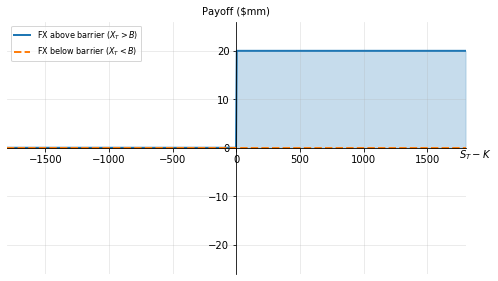

In [4]:
# Canonical: S>K & X>B. Two lines, one per FX state. Origin centred at the strike.
half_range = 1800
x = np.linspace(-half_range, half_range, 600)        # x = S_T - K
N_mm = NOTIONAL_PAY / 1e6
payoff_above = N_mm * (x > 0)                        # FX above barrier -> step at K
payoff_below = np.zeros_like(x)                       # FX below barrier -> nothing
ymax = N_mm * 1.3

fig, ax = plt.subplots(figsize=(7, 4))
ax.fill_between(x, 0, payoff_above, color="C0", alpha=0.25, step="pre")
ax.plot(x, payoff_above, color="C0", linewidth=2, label="FX above barrier ($X_T > B$)")
ax.plot(x, payoff_below, color="C1", linewidth=2, linestyle="--", label="FX below barrier ($X_T < B$)")
ax.set_xlim(-half_range, half_range); ax.set_ylim(-ymax, ymax)
ax.spines["left"].set_position("zero"); ax.spines["bottom"].set_position("zero")
ax.spines["top"].set_visible(False);    ax.spines["right"].set_visible(False)
ax.xaxis.set_label_coords(1.02, 0.5);   ax.yaxis.set_label_coords(0.5, 1.02)
ax.set_xlabel("$S_T - K$");             ax.set_ylabel("Payoff ($mm)", rotation=0, ha="center")
ax.legend(loc="upper left", fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Read.** A step function: $N$ if SPX is above strike *and* FX is above barrier; zero otherwise. With $S_0 = K = 7200$ and $X_0 = B = 156$, spot sits exactly at the corner — both legs are ATM and the four variants are nearly equally likely. The other three variants light up the other three quadrants the same way; together they tile the $(S_T, X_T)$ plane, and their prices sum to $N\,e^{-r_{USD}T}$ (verified below).

## Forwards under the model

The pricer uses the **USD risk-neutral measure**:

$$dS/S = (r_{USD} - q)\,dt + \sigma_S\, dW^S$$
$$dX/X = (r_{JPY} - r_{USD} + \sigma_X^2)\,dt + \sigma_X\, dW^X$$

The $+\sigma_X^2$ on the FX drift is the **quanto convexity correction** from changing numeraire from JPY-cash to USD-cash via Itô on $1/X$. Under the JPY measure, USDJPY drifts at the textbook Garman–Kohlhagen rate $r_{JPY} - r_{USD}$.

Two FX forwards are worth distinguishing:

1. **Market FX forward** (CIP, model-free):
   $$F_X^{\text{mkt}} = X_0\, e^{(r_{JPY}-r_{USD})\,T}$$
   This is the rate at which a USDJPY forward actually trades.

2. **USD-measure expectation** (model-dependent):
   $$\mathbb{E}^{Q^{USD}}[X_T] = X_0\, e^{(r_{JPY}-r_{USD}+\sigma_X^2)\,T}$$
   This is what the pricer uses internally; it differs from the market forward by the $\sigma_X^2 T$ convexity bump.

For SPX, the forward is unambiguous because SPX settles in USD:
$$F_S(T) = S_0\, e^{(r_{USD}-q)\,T}$$

In [5]:
# --- Forwards at maturity ---
F_S      = p.S0 * np.exp((p.r_d - p.q) * p.T)
F_X_mkt  = p.X0 * np.exp((p.r_f - p.r_d) * p.T)
mu_X     = (p.r_f - p.r_d) + p.sig_X**2
F_X_usd  = p.X0 * np.exp(mu_X * p.T)
quanto_bump = (np.exp(p.sig_X**2 * p.T) - 1) * 100

print(f"Forwards at T = {p.T:.2f}y")
print()
print(f"  SPX (model-free):       F_S         = {F_S:8.2f}      ({(F_S/p.S0-1)*100:+.2f}% vs spot)")
print(f"  USDJPY market (CIP):    F_X_mkt     = {F_X_mkt:8.2f}      ({(F_X_mkt/p.X0-1)*100:+.2f}% vs spot)")
print(f"  USDJPY USD-measure:     E^Q^USD[X]  = {F_X_usd:8.2f}      ({(F_X_usd/p.X0-1)*100:+.2f}% vs spot)")
print()
print(f"  Quanto convexity bump:  exp(sig_X^2 * T) - 1 = {quanto_bump:+.4f}%")
print(f"  USD > JPY rate -> JPY forward-strengthens (negative carry on USD long)")
print()
print(f"  Strike vs SPX fwd:      K is {(p.K/F_S-1)*100:+.1f}% relative to F_S")
print(f"  Barrier vs market fwd:  B is {(p.B/F_X_mkt-1)*100:+.1f}% relative to F_X_mkt")

Forwards at T = 0.50y

  SPX (model-free):       F_S         =  7308.81      (+1.51% vs spot)
  USDJPY market (CIP):    F_X_mkt     =   152.91      (-1.98% vs spot)
  USDJPY USD-measure:     E^Q^USD[X]  =   153.68      (-1.49% vs spot)

  Quanto convexity bump:  exp(sig_X^2 * T) - 1 = +0.5013%
  USD > JPY rate -> JPY forward-strengthens (negative carry on USD long)

  Strike vs SPX fwd:      K is -1.5% relative to F_S
  Barrier vs market fwd:  B is +2.0% relative to F_X_mkt


## Pricing the four variants

In [6]:
print(f"{'Variant':<14} {'Closed form':>14} {'MC est':>16} {'P_joint':>9} {'P_eq':>7} {'P_fx':>7}")
print("-" * 75)

results_d = {}
for eq_dir, fx_dir, lbl in variants_d:
    cf = price_double_digital(p, notional=NOTIONAL_PAY, eq_dir=eq_dir, fx_dir=fx_dir)
    mc = price_double_digital_mc(p, notional=NOTIONAL_PAY, eq_dir=eq_dir, fx_dir=fx_dir,
                                 n_paths=500_000, seed=42)
    results_d[(eq_dir, fx_dir)] = cf
    print(f"{lbl:<14} ${cf['price']/1e6:>10.4f}mm   ${mc['price']/1e6:>10.4f}mm   "
          f"{cf['P_joint']:>8.1%} {cf['P_eq']:>7.1%} {cf['P_fx']:>7.1%}")

total = sum(r["price"] for r in results_d.values())
pv_N = NOTIONAL_PAY * np.exp(-p.r_d * p.T)
print()
print(f"Sum of 4 variants:  ${total/1e6:.4f}mm")
print(f"PV of notional N:   ${pv_N/1e6:.4f}mm   (= N * exp(-r_USD * T))")
print(f"Difference:         ${(total - pv_N)/1e6:+.2e}mm  (zero to floating point)")

Variant           Closed form           MC est   P_joint    P_eq    P_fx
---------------------------------------------------------------------------
S>K & X>B      $    5.0848mm   $    5.0781mm      26.0%   53.0%   40.2%
S>K & X<B      $    5.2852mm   $    5.2824mm      27.0%   53.0%   59.8%
S<K & X>B      $    2.7815mm   $    2.7877mm      14.2%   47.0%   40.2%
S<K & X<B      $    6.4036mm   $    6.4067mm      32.7%   47.0%   59.8%

Sum of 4 variants:  $19.5550mm
PV of notional N:   $19.5550mm   (= N * exp(-r_USD * T))
Difference:         $+0.00e+00mm  (zero to floating point)


**Read.** Both legs are ATM, so each marginal is near 50%. The four joint variants are close to evenly priced — the differences (S>K dominating S<K slightly, X<B dominating X>B slightly) come from the equity drift (positive) and FX forward (below spot). The 4 variants sum to PV(notional) — every path lands in exactly one variant.

## Closed-form formula

The double digital price is just a discounted joint indicator probability:

$$V_0 = N\, e^{-r_{USD}\,T}\; M_2\!\big(\eta_S\, d_2^S,\; \eta_X\, d_2^X;\; \eta_S\eta_X\,\rho\big)$$

with

$$d_2^S = \frac{\ln(S_0/K) + (r_{USD} - q - \tfrac{1}{2}\sigma_S^2)\,T}{\sigma_S\sqrt{T}}$$

$$d_2^X = \frac{\ln(X_0/B) + (\mu_X - \tfrac{1}{2}\sigma_X^2)\,T}{\sigma_X\sqrt{T}}, \qquad \mu_X = r_{JPY} - r_{USD} + \sigma_X^2$$

No equity-asset numeraire change is needed because the payoff is a fixed cash amount, not a function of $S_T$. Compare to the conditional-european case where the first term in the formula reflected an asset-numeraire change.

## Cega — sign flips with $\eta_S\eta_X$

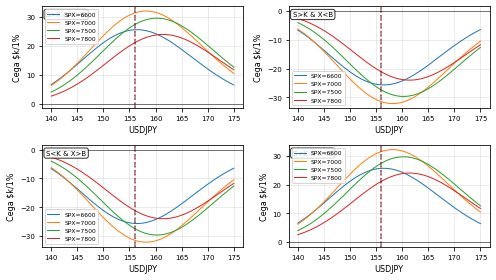

In [7]:
def dd_at(S0, X0, eq_dir="above", fx_dir="above", **ov):
    return price_double_digital(replace(p, S0=S0, X0=X0, **ov),
                                notional=NOTIONAL_PAY, eq_dir=eq_dir, fx_dir=fx_dir)["price"]

def dd_cega(S0, X0, eq_dir="above", fx_dir="above", drho=0.01, **ov):
    up = dd_at(S0, X0, eq_dir, fx_dir, **{**ov, "rho": p.rho + drho})
    dn = dd_at(S0, X0, eq_dir, fx_dir, **{**ov, "rho": p.rho - drho})
    return (up - dn) / 2

fx_grid = np.linspace(140, 175, 80)
fig, axes = plt.subplots(2, 2, figsize=(7, 4))
for ax, (eq_dir, fx_dir, lbl) in zip(axes.flat, variants_d):
    for S0 in [6600, 7000, 7500, 7800]:
        cs = [dd_cega(S0, x, eq_dir, fx_dir) / 1e3 for x in fx_grid]
        ax.plot(fx_grid, cs, label=f"SPX={S0}", linewidth=1)
    ax.axvline(p.B, color="k", ls="--", alpha=0.5)
    ax.axvline(p.X0, color="red", ls=":", alpha=0.5)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_xlabel("USDJPY", fontsize=8); ax.set_ylabel("Cega $k/1%", fontsize=8)
    ax.text(0.02, 0.95, lbl, transform=ax.transAxes, fontsize=7, va="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
    ax.legend(fontsize=6); ax.grid(alpha=0.3)
    ax.tick_params(labelsize=7)
plt.tight_layout(); plt.show()

**Read.** Cega is positive when `eq` and `fx` directions agree (`S>K & X>B`, `S<K & X<B`) and negative when they disagree. Intuitively: positive $\rho$ makes co-occurrence more likely (helps agreeing variants) and disagreement less likely (hurts opposing variants). This is a clean visual of the $\eta_S\eta_X$ sign in the closed form.

## Joint exercise probability surface

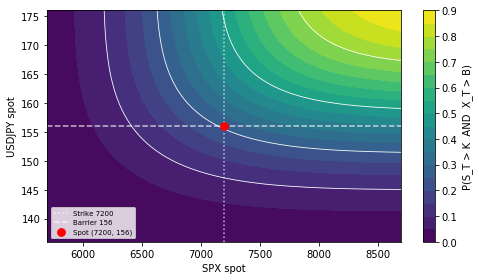

In [8]:
spx_g = np.linspace(p.K - 1500, p.K + 1500, 60)
fx_g  = np.linspace(p.B - 20,   p.B + 20,    60)
SS, XX = np.meshgrid(spx_g, fx_g)
PJ = np.zeros_like(SS)
for i in range(SS.shape[0]):
    for j in range(SS.shape[1]):
        PJ[i, j] = price_double_digital(replace(p, S0=SS[i,j], X0=XX[i,j]),
                                         notional=1.0, eq_dir="above", fx_dir="above")["P_joint"]

fig, ax = plt.subplots(figsize=(7, 4))
cf = ax.contourf(SS, XX, PJ, levels=20, cmap="viridis")
plt.colorbar(cf, ax=ax, label="P(S_T > K  AND  X_T > B)")
ax.contour(SS, XX, PJ, levels=[0.1, 0.25, 0.5, 0.75], colors="white", linewidths=0.8)
ax.axvline(p.K, color="white", ls=":", alpha=0.7, label=f"Strike {p.K:.0f}")
ax.axhline(p.B, color="white", ls="--", alpha=0.7, label=f"Barrier {p.B:.0f}")
ax.scatter([p.S0], [p.X0], color="red", s=60, zorder=5, label=f"Spot ({p.S0:.0f}, {p.X0:.0f})")
ax.set_xlabel("SPX spot"); ax.set_ylabel("USDJPY spot")
ax.legend(loc="lower left", fontsize=7); plt.tight_layout(); plt.show()

**Read.** Smooth contours of the joint cumulative probability. Spot sits at the corner where both legs are ATM, so the joint `S>K & X>B` probability hovers around 25–30%. Move spot up the diagonal and the probability rises quickly.

## Risk concentration: gamma at the strike

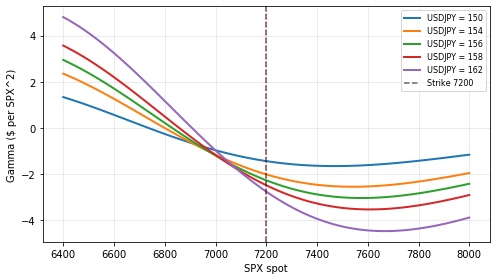

In [9]:
spx_grid_g = np.linspace(p.K - 800, p.K + 800, 80)

fig, ax = plt.subplots(figsize=(7, 4))
for X0 in [150, 154, 156, 158, 162]:
    gammas = []
    for s in spx_grid_g:
        bump_s = 0.005 * p.K
        d_up = (dd_at(s + bump_s, X0) - dd_at(s, X0)) / bump_s
        d_dn = (dd_at(s, X0) - dd_at(s - bump_s, X0)) / bump_s
        gammas.append((d_up - d_dn) / bump_s)
    ax.plot(spx_grid_g, gammas, label=f"USDJPY = {X0}", linewidth=2)

ax.axvline(p.K, color="k", ls="--", alpha=0.6, label=f"Strike {p.K:.0f}")
ax.axvline(p.S0, color="red", ls=":", alpha=0.5)
ax.set_xlabel("SPX spot"); ax.set_ylabel("Gamma ($ per SPX^2)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Read.** A digital's gamma is concentrated near the strike (and grows like $1/\sqrt{T - t}$ as expiry approaches). The peak height *also* depends on the FX level — closer to the barrier means higher gamma because the FX leg is most uncertain. This is the equity-side analog of the FX-vega sign-flip in the conditional european: digital risks are barrier-localised in *both* dimensions.

## Takeaways

1. **Four variants partition the (S, X) plane.** They sum to PV(notional). Closed form is the discounted joint indicator probability $M_2(\eta_S d_2^S, \eta_X d_2^X; \eta_S \eta_X \rho)$.

2. **No numeraire change needed.** Unlike the conditional european, the payoff is fixed cash, so we evaluate everything under the USD measure directly.

3. **Cega is the cleanest variant-flip diagnostic.** Sign of correlation risk depends purely on whether the eq and fx directions agree.

4. **Gamma is pathological.** A digital's gamma diverges at the strike near expiry. Static delta hedging close to expiry is operationally hard — desks usually replicate with tight call-spread overlays.

5. **For real marks**, the dominant risk premium is *call-spread vega*, not the digital itself: market-makers replicate digitals with vertical spreads of vanillas, and the bid/ask is driven by the spread width.